In [1]:
#==================================================
# 1. 멀티 쓰레딩을 이용한 로그 파일 병렬로 읽어오기
# 2. 단일 쓰레드 vs 멀티 쓰레드 처리시간 비교
#==================================================

In [3]:
import os
import time
import concurrent.futures
import matplotlib.pyplot as plt

In [11]:
LOG_DIR = "./data/log_files"

In [9]:
os.makedirs(LOG_DIR, exist_ok=True)

In [10]:
for i in range(1000):
    file_path = os.path.join(LOG_DIR, f'log_{i}.txt')                     # 파일 경로에 log_files/log_1.txt 형태로 파일 생성
    if not os.path.exists(file_path):                                     # 해당 파일이 존재하지 않을때만 새로 생성
        with open(file_path, 'w', encoding='utf-8') as f:                 # 쓰기모드로만 파일을 open
            f.write(('Sensor Value : ' + str(i) + '\n') * 5000)           # 센서 값 텍스트를 5000줄 작성

In [12]:
# 로그 폴더 내의 파일 경로를 리스트로 가져오기
files = [os.path.join(LOG_DIR,f) for f in os.listdir(LOG_DIR)]
files

['./data/log_files\\log_0.txt',
 './data/log_files\\log_1.txt',
 './data/log_files\\log_10.txt',
 './data/log_files\\log_100.txt',
 './data/log_files\\log_101.txt',
 './data/log_files\\log_102.txt',
 './data/log_files\\log_103.txt',
 './data/log_files\\log_104.txt',
 './data/log_files\\log_105.txt',
 './data/log_files\\log_106.txt',
 './data/log_files\\log_107.txt',
 './data/log_files\\log_108.txt',
 './data/log_files\\log_109.txt',
 './data/log_files\\log_11.txt',
 './data/log_files\\log_110.txt',
 './data/log_files\\log_111.txt',
 './data/log_files\\log_112.txt',
 './data/log_files\\log_113.txt',
 './data/log_files\\log_114.txt',
 './data/log_files\\log_115.txt',
 './data/log_files\\log_116.txt',
 './data/log_files\\log_117.txt',
 './data/log_files\\log_118.txt',
 './data/log_files\\log_119.txt',
 './data/log_files\\log_12.txt',
 './data/log_files\\log_120.txt',
 './data/log_files\\log_121.txt',
 './data/log_files\\log_122.txt',
 './data/log_files\\log_123.txt',
 './data/log_files\\l

In [13]:
# 파일 읽어오기
def read_file(path: str) -> str:
    with open(path, 'r', encoding='utf-8') as f:          # 읽기 모드로 파일 가져오기
        content = f.read()                                # 파일 전체 내용을 읽어오기
    return content                                        # 내용 가져오기

In [14]:
# 단일 쓰레드
start_single = time.time()                               # 시간 측정
for path_ in files:                                      # 전체 파일을 순차적으로 읽음
    _ = read_file(path_)                                 # 내용 읽어오고
end_single = time.time()                                 # 종료 시간 기록 
elapsed_single = end_single - start_single               # 걸린 시간 계산

print(f"단일 쓰레드 처리시간 : {elapsed_single:.4f}초")

단일 쓰레드 처리시간 : 8.0896초


In [16]:
# 멀티 쓰레드
start_multi = time.time()
with concurrent.futures.ThreadPoolExecutor() as executor:
    list(executor.map(read_file, files))
end_multi = time.time()
elapsed_multi = end_multi - start_multi
print(f"멀티 쓰레드 처리시간 : {elapsed_multi:.4f}초")

멀티 쓰레드 처리시간 : 0.3937초


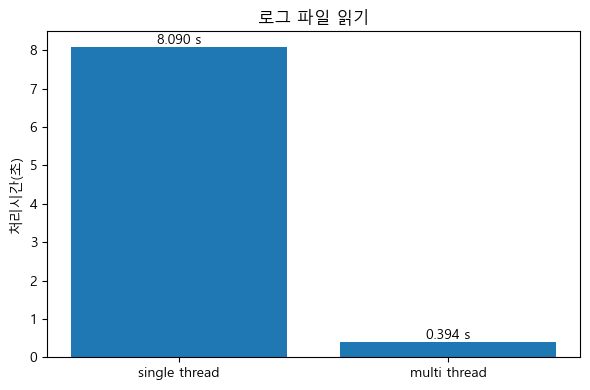

In [17]:
# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지

## 성능 비교 시각화
labels = ['single thread','multi thread']
times = [elapsed_single, elapsed_multi]

plt.figure(figsize=(6,4))
plt.bar(labels, times)
plt.ylabel('처리시간(초)')
plt.title('로그 파일 읽기')


# 각 막대 위에 시간 값 표기
for i, v in enumerate(times):
    plt.text(i, v, f'{v:.3f} s',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
#=========================================================================
# AsyncIO를 이용한 API 호출 
#=========================================================================
# 동기 방식 vs 비동기 방식 처리시간을 비교